# LLM Baseline: Role Choice Prediction

## Goal
Use an LLM (via OpenRouter) as a baseline model for predicting player role choices.
Compare against the existing computational models (Random, Random Walk, Optimal, Bayesian-Value, Bayesian-Belief).

## Model
- **Provider**: OpenRouter
- **Model**: `google/gemini-3.1-flash-lite-preview`
- **API Key**: loaded from `.env`

## Approach
For each team-round, at each stage, prompt the LLM with:
1. Game rules (roles, actions, how stats affect damage/healing)
2. Player stats (STR/DEF/SUP) for all 3 players
3. Current game state (team HP, enemy HP, enemy intent)
4. Teacher-forced history of previous role choices and outcomes

Ask for a probability distribution over roles for each player (JSON format).
Evaluate using per-player log-likelihood with lapse rate and team-level Pearson r.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import hashlib
import time
from pathlib import Path
from collections import defaultdict
from dotenv import load_dotenv
import os

from openai import OpenAI

# Shared package
from shared import EXPORTS_DIR, DATA_ROOT
from shared.constants import (
    F, T, M,
    ROLE_NAMES, ROLE_SHORT, ROLE_CHAR_TO_IDX, GAME_ROLE_TO_IDX,
    ALL_ROLE_COMBOS, MAX_STAGES, TURNS_PER_STAGE,
    ROLE_COMBO_TO_ENV_NUM,
)
from shared.parsing import canonical_combo, get_canonical_combos
from shared.inference import (
    utility_based_prior, uniform_prior,
    bayesian_update, action_prob, preferred_action, game_step,
    softmax_role_dist, combo_marginal,
    ATTACK, DEFEND, HEAL,
)
from shared.evaluation import (
    run_predictions, compute_pearson, compute_log_likelihood, extract_metrics,
)
from shared.data_loading import load_all_exports, to_dataframe
from shared.env_loading import make_env_loader

# Load API key
ENV_PATH = Path(__file__).parent / '.env' if '__file__' in dir() else Path('.env')
load_dotenv(Path('analysis/experiments/2026-03-29_llm_baseline/.env'))

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
)
MODEL = "google/gemini-3.1-flash-lite-preview"
CACHE_PATH = Path("analysis/experiments/2026-03-29_llm_baseline/llm_cache.json")

print("Imports OK")

Imports OK


## Step 1: Load Data

Same approach as individual_model_fitting: load per-player records, build team-round records with env configs.

In [2]:
# Load per-player records (human rounds only, no dropout games)
DATA_DIRS = [
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-06-09-54-19',
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-18-15-47-09',
]
player_records = load_all_exports(data_dirs=DATA_DIRS, include_bot_rounds=False, include_dropout_games=False)
df = to_dataframe(player_records)
print(f"\n{len(df)} player-rounds, {df['participant_id'].nunique()} unique participants")
print(f"Games: {df['game_id'].nunique()}")

# Build team-round records
env_loader = make_env_loader()
team_records = []
grouped = df.groupby(['game_id', 'round_number'])

for (game_id, round_num), group in grouped:
    if len(group) != 3:
        print(f"WARNING: {game_id} R{round_num} has {len(group)} players, skipping")
        continue
    
    group = group.sort_values('player_id')
    players = group.to_dict('records')
    participant_ids = [p['participant_id'] for p in players]
    
    n_stages = min(p['n_stages'] for p in players)
    stage_roles = []
    for s in range(n_stages):
        combo = ''.join(ROLE_SHORT[players[pos]['role_idxs'][s]] for pos in range(3))
        stage_roles.append(combo)
    
    if not stage_roles:
        continue
    
    config = players[0]['config']
    optimal_roles_idx = config.get('optimalRoles', [])
    role_combo = ''.join(ROLE_SHORT[ri] for ri in optimal_roles_idx)
    stat_profile = players[0]['stat_profile_id']
    lds = [int(c) for c in players[0]['enemy_intent_sequence']]
    
    # Get per-player stats as list of dicts
    all_player_stats = [players[pos]['player_stats'] for pos in range(3)]
    
    env_config = env_loader(role_combo=role_combo)
    
    team_records.append({
        'game_id': game_id,
        'round_number': round_num,
        'env_id': f"{stat_profile}_{role_combo}",
        'stat_profile': stat_profile,
        'optimal_roles': role_combo,
        'lds': lds,
        'stage_roles': stage_roles,
        'env_config': env_config,
        'participant_ids': participant_ids,
        'all_player_stats': all_player_stats,
    })

print(f"\nBuilt {len(team_records)} team-rounds")
print(f"Total stages: {sum(len(r['stage_roles']) for r in team_records)}")
print(f"Environments: {sorted(set(r['env_id'] for r in team_records))}")

Loaded bayesian-role-specialization-2026-03-06-09-54-19: 54 player-rounds
Loaded bayesian-role-specialization-2026-03-18-15-47-09: 144 player-rounds
Total: 198 player-rounds from 2 exports

198 player-rounds, 33 unique participants
Games: 11

Built 66 team-rounds
Total stages: 234
Environments: ['114_222_222_MFF', '222_222_222_FFF', '411_141_114_FFM', '411_141_114_FTF', '411_141_114_FTM', '411_222_222_FMM']


## Step 2: LLM Prompt Design & API Infrastructure

### Prompt strategy
- **System prompt**: Explains the game rules, roles, actions, and how stats work
- **User prompt** (per stage): Player stats, current game state, enemy intent, and teacher-forced history of previous stages
- **Output**: JSON with probability distributions over roles for each player

### Caching
All LLM responses are cached to `llm_cache.json` keyed by a hash of the prompt content.
This avoids redundant API calls across notebook re-runs.

In [3]:
SYSTEM_PROMPT = """You are predicting human behavior in a multiplayer role-playing game experiment.

## Game Rules
- A team of 3 players fights a boss enemy across multiple stages.
- Each stage, every player picks a role: Fighter (F), Tank (T), or Medic (M).
- Each stage has 2 turns. Each turn, every player performs their role's action.

## Role Actions
- **Fighter**: Always ATTACKs. Damage dealt = player's STR stat.
- **Tank**: BLOCKs when the enemy attacks (reduces incoming damage by player's DEF stat). ATTACKs when the enemy doesn't attack (damage = player's STR stat).
- **Medic**: HEALs when team HP < max (heals = player's SUP stat). ATTACKs when team is at full HP (damage = player's STR stat).

## Stats
Each player has 3 stats: STR (strength), DEF (defense), SUP (support).
- Higher STR → better Fighter (more attack damage)
- Higher DEF → better Tank (more damage blocked)
- Higher SUP → better Medic (more healing)

## Enemy
The boss attacks on some turns (shown as enemy intent: 1=attacks, 0=doesn't).
Boss attack damage is fixed. Blocking reduces it.

## Player Behavior
Players are real humans in an experiment. They tend to:
- Pick roles matching their best stat (high STR → Fighter, high DEF → Tank, high SUP → Medic)
- Sometimes explore or adapt based on what works
- Copy successful strategies from previous stages
- Show some randomness/experimentation, especially early on

## Your Task
Given the game state and history, predict the probability distribution over roles (F, T, M) for each player at the NEXT stage. Output valid JSON only."""


def build_user_prompt(record, stage_idx):
    """Build the user prompt for a specific stage prediction."""
    env = record['env_config']
    lds = record['lds']
    player_stats = record['all_player_stats']
    team_max_hp = int(env['team_max_hp'])
    enemy_max_hp = int(env['enemy_max_hp'])
    
    lines = []
    
    # Player stats
    lines.append("## Player Stats")
    for i in range(3):
        s = player_stats[i]
        best = max(s, key=s.get)
        lines.append(f"- Player {i+1}: STR={s['STR']}, DEF={s['DEF']}, SUP={s['SUP']} (best: {best})")
    
    # Current game state - simulate forward using teacher-forced history
    team_hp = float(team_max_hp)
    enemy_hp = float(enemy_max_hp)
    ps_array = env['player_stats']  # (3,3) numpy array
    boss_damage = env['boss_damage']
    turn_idx = 0
    
    # History of previous stages
    if stage_idx > 0:
        lines.append("\n## Previous Stages")
        for s in range(stage_idx):
            combo = record['stage_roles'][s]
            roles_desc = [ROLE_NAMES[ROLE_CHAR_TO_IDX[c]] for c in combo]
            
            stage_start_hp = team_hp
            stage_start_ehp = enemy_hp
            
            # Get intents for this stage's turns
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in combo]
            stage_intents = []
            for t in range(TURNS_PER_STAGE):
                if turn_idx < len(lds):
                    intent = lds[turn_idx]
                    stage_intents.append(intent)
                    actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                    team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, ps_array, boss_damage, team_max_hp)
                    turn_idx += 1
            
            intent_str = ', '.join('attacks' if x == 1 else 'idle' for x in stage_intents)
            lines.append(f"Stage {s+1}: P1={roles_desc[0]}, P2={roles_desc[1]}, P3={roles_desc[2]}")
            lines.append(f"  Enemy: [{intent_str}] | Team HP: {int(stage_start_hp)}→{int(team_hp)} | Enemy HP: {int(stage_start_ehp)}→{int(enemy_hp)}")
    
    # Current state for prediction
    lines.append(f"\n## Current State (Stage {stage_idx + 1})")
    lines.append(f"- Team HP: {int(team_hp)}/{team_max_hp}")
    lines.append(f"- Enemy HP: {int(enemy_hp)}/{enemy_max_hp}")
    
    # Enemy intent for upcoming turns
    upcoming_intents = []
    for t in range(TURNS_PER_STAGE):
        ti = turn_idx + t
        if ti < len(lds):
            upcoming_intents.append('attacks' if lds[ti] == 1 else 'idle')
    if upcoming_intents:
        lines.append(f"- Enemy will: [{', '.join(upcoming_intents)}]")
    
    lines.append(f"\nPredict each player's role choice distribution for Stage {stage_idx + 1}.")
    lines.append('Respond with ONLY this JSON (no other text):')
    lines.append('{"P1": {"F": prob, "T": prob, "M": prob}, "P2": {"F": prob, "T": prob, "M": prob}, "P3": {"F": prob, "T": prob, "M": prob}}')
    
    return '\n'.join(lines)


# Test prompt generation
test_rec = team_records[0]
print("=== SYSTEM PROMPT ===")
print(SYSTEM_PROMPT[:200] + "...")
print(f"\n=== USER PROMPT (stage 0) ===")
print(build_user_prompt(test_rec, 0))
if len(test_rec['stage_roles']) > 1:
    print(f"\n=== USER PROMPT (stage 1, with history) ===")
    print(build_user_prompt(test_rec, 1))

=== SYSTEM PROMPT ===
You are predicting human behavior in a multiplayer role-playing game experiment.

## Game Rules
- A team of 3 players fights a boss enemy across multiple stages.
- Each stage, every player picks a rol...

=== USER PROMPT (stage 0) ===
## Player Stats
- Player 1: STR=4, DEF=1, SUP=1 (best: STR)
- Player 2: STR=2, DEF=2, SUP=2 (best: STR)
- Player 3: STR=2, DEF=2, SUP=2 (best: STR)

## Current State (Stage 1)
- Team HP: 10/10
- Enemy HP: 30/30
- Enemy will: [attacks, idle]

Predict each player's role choice distribution for Stage 1.
Respond with ONLY this JSON (no other text):
{"P1": {"F": prob, "T": prob, "M": prob}, "P2": {"F": prob, "T": prob, "M": prob}, "P3": {"F": prob, "T": prob, "M": prob}}

=== USER PROMPT (stage 1, with history) ===
## Player Stats
- Player 1: STR=4, DEF=1, SUP=1 (best: STR)
- Player 2: STR=2, DEF=2, SUP=2 (best: STR)
- Player 3: STR=2, DEF=2, SUP=2 (best: STR)

## Previous Stages
Stage 1: P1=Fighter, P2=Tank, P3=Tank
  Enemy: [attacks, id

## Step 3: API Calling with Caching

Cache all LLM responses to disk so we don't re-run on every notebook execution.
Parse JSON responses into per-player probability distributions.

In [4]:
# --- Cache management ---
def load_cache():
    if CACHE_PATH.exists():
        with open(CACHE_PATH) as f:
            return json.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_PATH, 'w') as f:
        json.dump(cache, f, indent=2)

def cache_key(system, user):
    content = f"{system}\n---\n{user}"
    return hashlib.sha256(content.encode()).hexdigest()[:16]


# --- API calling ---
def call_llm(system_prompt, user_prompt, cache, temperature=0.3):
    """Call the LLM with caching. Returns raw response text."""
    key = cache_key(system_prompt, user_prompt)
    if key in cache:
        return cache[key], True  # (response, was_cached)
    
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        temperature=temperature,
        max_tokens=256,
    )
    text = response.choices[0].message.content.strip()
    cache[key] = text
    return text, False


def parse_llm_response(text):
    """Parse LLM JSON response into per-player marginals.
    
    Returns list of 3 numpy arrays (one per player), each length 3 (F, T, M probs).
    Returns None if parsing fails.
    """
    # Try to extract JSON from response (handle markdown code blocks)
    clean = text.strip()
    if clean.startswith("```"):
        clean = clean.split("\n", 1)[1] if "\n" in clean else clean[3:]
        if clean.endswith("```"):
            clean = clean[:-3]
        clean = clean.strip()
    
    try:
        data = json.loads(clean)
    except json.JSONDecodeError:
        return None
    
    marginals = []
    for p in ["P1", "P2", "P3"]:
        if p not in data:
            return None
        d = data[p]
        probs = np.array([float(d.get("F", 0)), float(d.get("T", 0)), float(d.get("M", 0))])
        total = probs.sum()
        if total > 0:
            probs /= total
        else:
            probs = np.ones(3) / 3.0
        marginals.append(probs)
    return marginals


# Quick test: single API call
cache = load_cache()
test_prompt = build_user_prompt(team_records[0], 0)
response, was_cached = call_llm(SYSTEM_PROMPT, test_prompt, cache)
print(f"Cached: {was_cached}")
print(f"Response: {response}")
parsed = parse_llm_response(response)
if parsed:
    for i, m in enumerate(parsed):
        print(f"  P{i+1}: F={m[0]:.3f}, T={m[1]:.3f}, M={m[2]:.3f}")
else:
    print("  PARSE FAILED")
save_cache(cache)

Cached: False
Response: {"P1": {"F": 0.8, "T": 0.1, "M": 0.1}, "P2": {"F": 0.5, "T": 0.25, "M": 0.25}, "P3": {"F": 0.5, "T": 0.25, "M": 0.25}}
  P1: F=0.800, T=0.100, M=0.100
  P2: F=0.500, T=0.250, M=0.250
  P3: F=0.500, T=0.250, M=0.250


## Step 4: Run LLM on All Team-Rounds

Run the LLM for every (team-round, stage) combination. Track parse failures and cache hits.

In [5]:
# Run LLM predictions for all team-rounds and stages
cache = load_cache()
initial_cache_size = len(cache)

# Store results: llm_predictions[rec_idx][stage_idx] = list of 3 marginals (or None)
llm_predictions = {}
n_calls = 0
n_cached = 0
n_parse_fail = 0
n_total = sum(len(r['stage_roles']) for r in team_records)

print(f"Total predictions needed: {n_total}")
print(f"Cache has {initial_cache_size} entries\n")

for rec_idx, rec in enumerate(team_records):
    llm_predictions[rec_idx] = {}
    for s in range(len(rec['stage_roles'])):
        user_prompt = build_user_prompt(rec, s)
        
        try:
            response, was_cached = call_llm(SYSTEM_PROMPT, user_prompt, cache)
        except Exception as e:
            print(f"  API error at rec {rec_idx} stage {s}: {e}")
            llm_predictions[rec_idx][s] = None
            time.sleep(2)
            continue
        
        n_calls += 1
        if was_cached:
            n_cached += 1
        else:
            # Rate limiting: small delay between API calls
            time.sleep(0.1)
        
        parsed = parse_llm_response(response)
        if parsed is None:
            n_parse_fail += 1
            if n_parse_fail <= 5:
                print(f"  Parse fail at rec {rec_idx} stage {s}: {response[:100]}")
        llm_predictions[rec_idx][s] = parsed
    
    # Save cache periodically
    if (rec_idx + 1) % 20 == 0:
        save_cache(cache)
        pct = sum(1 for r in llm_predictions.values() for v in r.values() if v is not None) / max(n_calls, 1) * 100
        print(f"  Progress: {rec_idx + 1}/{len(team_records)} records, {n_calls} calls, {pct:.0f}% parse success")

save_cache(cache)

n_success = sum(1 for r in llm_predictions.values() for v in r.values() if v is not None)
print(f"\nDone! {n_calls} calls ({n_cached} cached, {n_calls - n_cached} new)")
print(f"Parse success: {n_success}/{n_total} ({n_success/n_total*100:.1f}%)")
print(f"Parse failures: {n_parse_fail}")

Total predictions needed: 234
Cache has 1 entries



  Progress: 20/66 records, 77 calls, 100% parse success


  Progress: 40/66 records, 143 calls, 100% parse success


  Progress: 60/66 records, 211 calls, 100% parse success



Done! 234 calls (86 cached, 148 new)
Parse success: 234/234 (100.0%)
Parse failures: 0


## Step 5: Build LLM Model Function

Wrap LLM predictions into the same model interface as the other models:
`model(record) -> list[list[np.array]]` — per-stage, per-player marginals.

In [6]:
# Build record index for fast lookup
rec_index = {(r['game_id'], r['round_number']): i for i, r in enumerate(team_records)}

def model_llm(record):
    """LLM model function matching the interface of other models."""
    key = (record['game_id'], record['round_number'])
    rec_idx = rec_index.get(key)
    if rec_idx is None:
        return [[np.ones(3) / 3.0 for _ in range(3)] for _ in record['stage_roles']]
    
    stage_marginals = []
    for s in range(len(record['stage_roles'])):
        preds = llm_predictions.get(rec_idx, {}).get(s)
        if preds is None:
            stage_marginals.append([np.ones(3) / 3.0 for _ in range(3)])
        else:
            stage_marginals.append(preds)
    return stage_marginals


# Also define the other baseline models for comparison
def model_random(record):
    uniform = np.ones(3) / 3.0
    return [[uniform.copy() for _ in range(3)] for _ in record['stage_roles']]

def make_model_random_walk(eps=0.38):
    def model(record):
        stage_marginals = []
        for s, combo in enumerate(record['stage_roles']):
            if s == 0:
                stage_marginals.append([np.ones(3) / 3.0 for _ in range(3)])
            else:
                prev_combo = record['stage_roles'][s - 1]
                player_margs = []
                for i in range(3):
                    marg = np.full(3, eps / 2.0)
                    prev_role_idx = ROLE_CHAR_TO_IDX[prev_combo[i]]
                    marg[prev_role_idx] = 1.0 - eps
                    player_margs.append(marg)
                stage_marginals.append(player_margs)
        return stage_marginals
    return model

def make_model_bayesian_belief(tau_prior=2.0, epsilon=0.5):
    def model(record):
        env = record['env_config']
        player_stats = env['player_stats']
        boss_damage = env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']
        
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        stage_marginals = []
        turn_idx = 0
        
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                break
            per_agent = []
            for i in range(3):
                marg = np.sum(prior, axis=tuple(j for j in range(3) if j != i))
                total = marg.sum()
                per_agent.append(marg / total if total > 0 else np.ones(3) / 3)
            stage_marginals.append(per_agent)
            
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                    break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return stage_marginals
    return model

def make_model_bayesian_value(tau_prior=5.6, tau_softmax=0.1, epsilon=0.2):
    def model(record):
        env = record['env_config']
        values = env['values']
        player_stats = env['player_stats']
        boss_damage = env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']
        
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        stage_marginals = []
        turn_idx = 0
        
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                break
            intent = record['lds'][turn_idx]
            thp = int(min(max(0, team_hp), team_max_hp))
            ehp = int(min(max(0, enemy_hp), enemy_max_hp))
            per_agent = [softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax) for i in range(3)]
            stage_marginals.append(per_agent)
            
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0:
                    break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return stage_marginals
    return model

MODELS = {
    'Random': model_random,
    'Random Walk': make_model_random_walk(eps=0.38),
    'Bayesian-Belief': make_model_bayesian_belief(tau_prior=2.0, epsilon=0.5),
    'Bayesian-Value': make_model_bayesian_value(tau_prior=5.6, tau_softmax=0.1, epsilon=0.2),
    'LLM (Gemini Flash Lite)': model_llm,
}

# Sanity check
test_rec = team_records[0]
for name, fn in MODELS.items():
    margs = fn(test_rec)
    print(f"{name}: {len(margs)} stages, P1 stage 0 = {margs[0][0].round(3)}")

Random: 3 stages, P1 stage 0 = [0.333 0.333 0.333]
Random Walk: 3 stages, P1 stage 0 = [0.333 0.333 0.333]
Bayesian-Belief: 3 stages, P1 stage 0 = [0.691 0.154 0.154]
Bayesian-Value: 3 stages, P1 stage 0 = [1. 0. 0.]
LLM (Gemini Flash Lite): 3 stages, P1 stage 0 = [0.8 0.1 0.1]


## Step 6: Per-Player Log-Likelihood Evaluation

Compute per-player log-likelihoods with lapse rate (λ=0.05), same as individual_model_fitting.

In [7]:
LAPSE_RATE = 0.05
UNIFORM = np.ones(3) / 3.0
model_names = list(MODELS.keys())

def apply_lapse(marginal, lapse=LAPSE_RATE):
    return (1.0 - lapse) * marginal + lapse * UNIFORM

# Accumulate per-player log-likelihoods
player_ll = {name: defaultdict(float) for name in MODELS}
player_n_stages = defaultdict(int)
all_pids = set()

for rec in team_records:
    model_outputs = {name: fn(rec) for name, fn in MODELS.items()}
    for s, human_combo in enumerate(rec['stage_roles']):
        for pos in range(3):
            pid = rec['participant_ids'][pos]
            all_pids.add(pid)
            actual_role_idx = ROLE_CHAR_TO_IDX[human_combo[pos]]
            player_n_stages[pid] += 1
            for name in MODELS:
                margs = model_outputs[name]
                if s < len(margs):
                    prob = apply_lapse(margs[s][pos])[actual_role_idx]
                else:
                    prob = 1.0 / 3.0
                player_ll[name][pid] += np.log(max(prob, 1e-20))

# Build DataFrame
ll_rows = []
for pid in sorted(all_pids):
    row = {'participant_id': pid, 'n_stages': player_n_stages[pid]}
    for name in MODELS:
        row[f'll_{name}'] = player_ll[name][pid]
    ll_rows.append(row)
ll_df = pd.DataFrame(ll_rows)

# Summary: mean LL per stage per model
print(f"Per-player log-likelihoods (λ={LAPSE_RATE}, {len(all_pids)} participants):\n")
for name in model_names:
    total_ll = ll_df[f'll_{name}'].sum()
    total_stages = ll_df['n_stages'].sum()
    mean_ll = total_ll / total_stages
    print(f"  {name:30s}: total LL = {total_ll:8.1f}, mean LL/stage = {mean_ll:.4f}")

print(f"\nChance level (uniform): {np.log(1/3):.4f} per stage")

Per-player log-likelihoods (λ=0.05, 33 participants):

  Random                        : total LL =   -771.2, mean LL/stage = -1.0986
  Random Walk                   : total LL =   -658.8, mean LL/stage = -0.9384
  Bayesian-Belief               : total LL =   -614.1, mean LL/stage = -0.8748
  Bayesian-Value                : total LL =  -1081.4, mean LL/stage = -1.5405
  LLM (Gemini Flash Lite)       : total LL =   -672.3, mean LL/stage = -0.9577

Chance level (uniform): -1.0986 per stage


## Step 7: Team-Level Pearson r Evaluation

Use `shared.evaluation` to compute combo_r and marg_r for all models.

In [8]:
def make_aggregate_predict(model_fn):
    """Wrap a per-player marginal model into the predict_fn interface for run_predictions."""
    def predict(record):
        margs = model_fn(record)
        preds = []
        for s, human_combo in enumerate(record['stage_roles']):
            if s >= len(margs):
                break
            predicted_dist = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        combo = ROLE_SHORT[r0] + ROLE_SHORT[r1] + ROLE_SHORT[r2]
                        predicted_dist[combo] = float(margs[s][0][r0] * margs[s][1][r1] * margs[s][2][r2])
            preds.append({
                'predicted_dist': predicted_dist,
                'human_combo': human_combo,
                'model_marginal': np.mean(margs[s], axis=0),
            })
        return preds
    return predict

# Compute metrics for all models
all_metrics = {}
for name, fn in MODELS.items():
    results = run_predictions(team_records, make_aggregate_predict(fn))
    metrics = extract_metrics(compute_pearson(results))
    ll = compute_log_likelihood(results)
    mean_ll = np.mean([v['mean_ll'] for v in ll.values()]) if ll else float('nan')
    all_metrics[name] = {**metrics, 'mean_ll': mean_ll}

# Display comparison table
print("=== Model Comparison ===\n")
comparison_df = pd.DataFrame([
    {'Model': name, 'combo_r': m['combo_r'], 'marg_r': m['marg_r'], 'mean_ll': m['mean_ll']}
    for name, m in all_metrics.items()
]).set_index('Model')

print(comparison_df.to_string(float_format='{:.4f}'.format))
print(f"\n(Random baseline combo_r: {all_metrics['Random']['combo_r']:.4f})")

=== Model Comparison ===

                         combo_r  marg_r  mean_ll
Model                                            
Random                    0.1567 -0.0000  -3.2958
Random Walk               0.3855  0.4576  -2.8078
Bayesian-Belief           0.4732  0.3582  -2.6613
Bayesian-Value            0.3728  0.5114 -25.1469
LLM (Gemini Flash Lite)   0.4234  0.3437  -2.9274

(Random baseline combo_r: 0.1567)


/Users/jolow/coding/bayesian-role-specialization/analysis/shared/evaluation.py:129: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  r, p = pearsonr(marg_m, marg_h)
/Users/jolow/coding/bayesian-role-specialization/analysis/shared/evaluation.py:126: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(combo_m, combo_h)
/Users/jolow/coding/bayesian-role-specialization/analysis/shared/evaluation.py:129: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(marg_m, marg_h)
/Users/jolow/coding/bayesian-role-specialization/analysis/shared/evaluation.py:143: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  r, p = pearsonr(global_marg_m, global_marg_h)


## Step 8: Visualizations

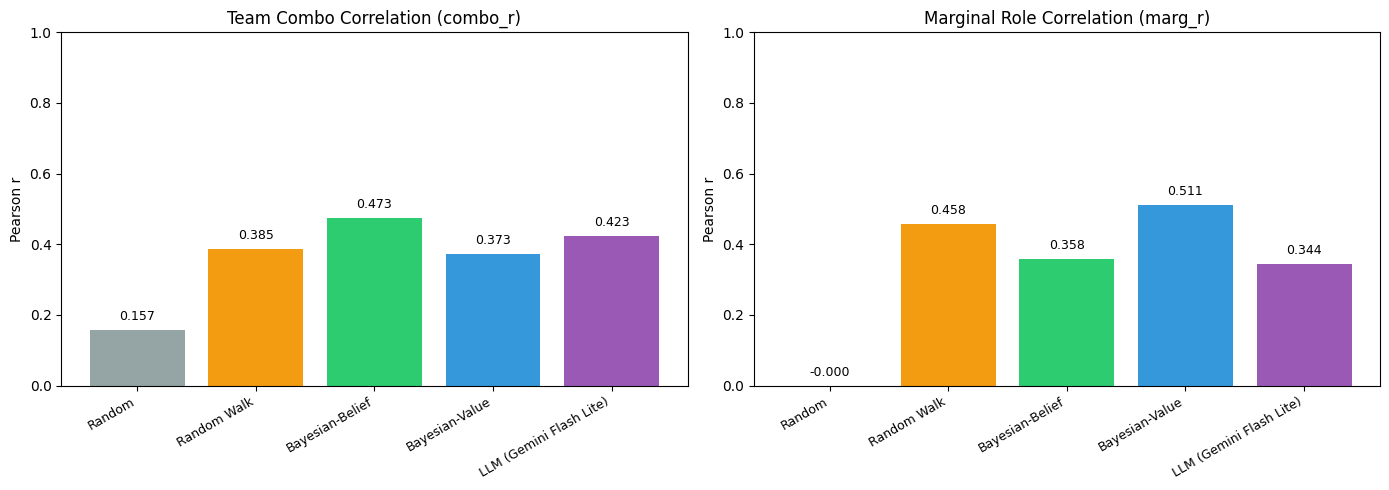

Saved model_comparison.png


In [9]:
# --- Bar chart: combo_r and marg_r comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = list(all_metrics.keys())
combo_vals = [all_metrics[n]['combo_r'] for n in labels]
marg_vals = [all_metrics[n]['marg_r'] for n in labels]
colors = ['#95a5a6', '#f39c12', '#2ecc71', '#3498db', '#9b59b6']

for ax, vals, title, ylabel in [
    (axes[0], combo_vals, 'Team Combo Correlation (combo_r)', 'Pearson r'),
    (axes[1], marg_vals, 'Marginal Role Correlation (marg_r)', 'Pearson r'),
]:
    bars = ax.bar(range(len(labels)), vals, color=colors[:len(labels)])
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.axhline(y=0, color='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('analysis/experiments/2026-03-29_llm_baseline/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved model_comparison.png")

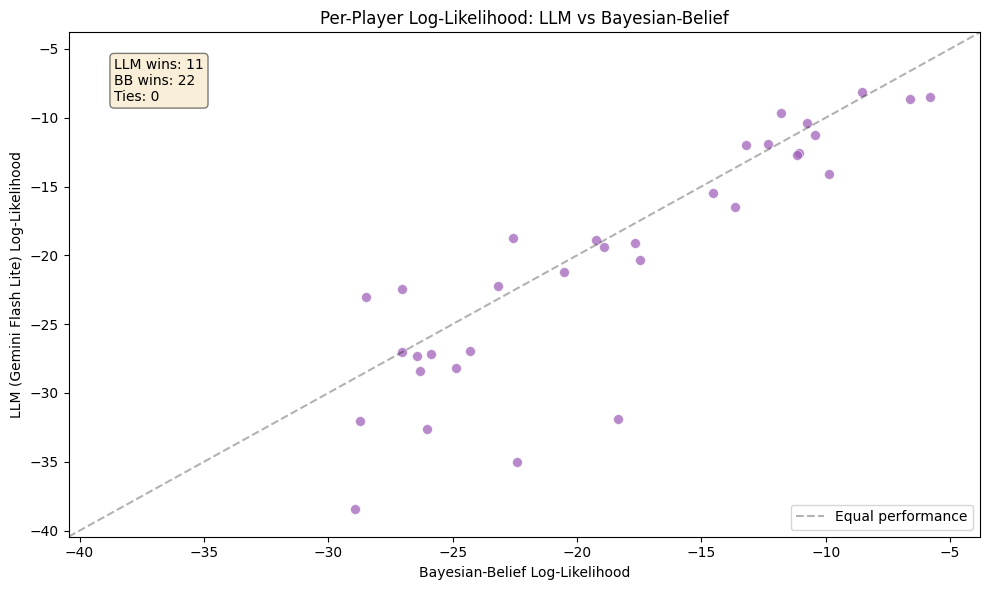

Saved ll_scatter.png


In [10]:
# --- Per-player LL comparison: LLM vs best computational model ---
fig, ax = plt.subplots(figsize=(10, 6))

# For each player, compare LLM LL vs Bayesian-Belief LL
llm_lls = ll_df[f'll_LLM (Gemini Flash Lite)'].values
bb_lls = ll_df[f'll_Bayesian-Belief'].values

ax.scatter(bb_lls, llm_lls, alpha=0.7, s=50, c='#9b59b6', edgecolors='white', linewidth=0.5)
lims = [min(bb_lls.min(), llm_lls.min()) - 2, max(bb_lls.max(), llm_lls.max()) + 2]
ax.plot(lims, lims, 'k--', alpha=0.3, label='Equal performance')
ax.set_xlabel('Bayesian-Belief Log-Likelihood')
ax.set_ylabel('LLM (Gemini Flash Lite) Log-Likelihood')
ax.set_title('Per-Player Log-Likelihood: LLM vs Bayesian-Belief')
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)

# Count wins
llm_wins = (llm_lls > bb_lls).sum()
bb_wins = (bb_lls > llm_lls).sum()
ties = (llm_lls == bb_lls).sum()
ax.text(0.05, 0.95, f'LLM wins: {llm_wins}\nBB wins: {bb_wins}\nTies: {ties}',
        transform=ax.transAxes, verticalalignment='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('analysis/experiments/2026-03-29_llm_baseline/ll_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ll_scatter.png")

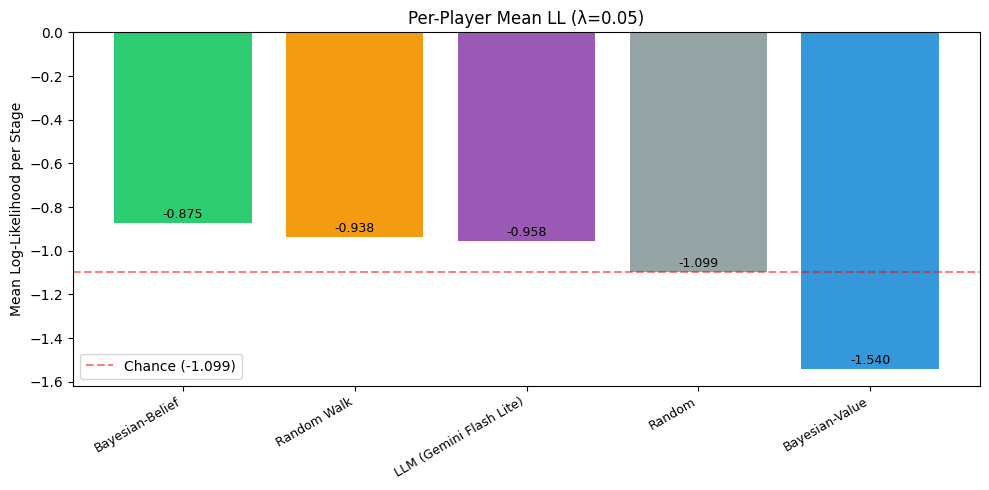

Saved mean_ll_comparison.png


In [11]:
# --- Mean LL per stage bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))

total_stages = ll_df['n_stages'].sum()
mean_lls = {name: ll_df[f'll_{name}'].sum() / total_stages for name in model_names}
sorted_names = sorted(mean_lls, key=mean_lls.get, reverse=True)

bars = ax.bar(range(len(sorted_names)), [mean_lls[n] for n in sorted_names],
              color=[colors[model_names.index(n)] for n in sorted_names])
ax.set_xticks(range(len(sorted_names)))
ax.set_xticklabels(sorted_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mean Log-Likelihood per Stage')
ax.set_title(f'Per-Player Mean LL (λ={LAPSE_RATE})')
ax.axhline(y=np.log(1/3), color='red', linestyle='--', alpha=0.5, label=f'Chance ({np.log(1/3):.3f})')
ax.legend()

for bar, name in zip(bars, sorted_names):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{mean_lls[name]:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('analysis/experiments/2026-03-29_llm_baseline/mean_ll_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved mean_ll_comparison.png")

## Step 9: LLM Prediction Analysis

Examine the LLM's prediction patterns — does it just predict stat-optimal roles, or does it show more nuance?

LLM Prediction Analysis (702 player-stage predictions):

  Mean entropy: 0.755 (uniform=1.099)
  Argmax accuracy (vs actual):    55.8%
  Argmax = stat-optimal:          71.8%


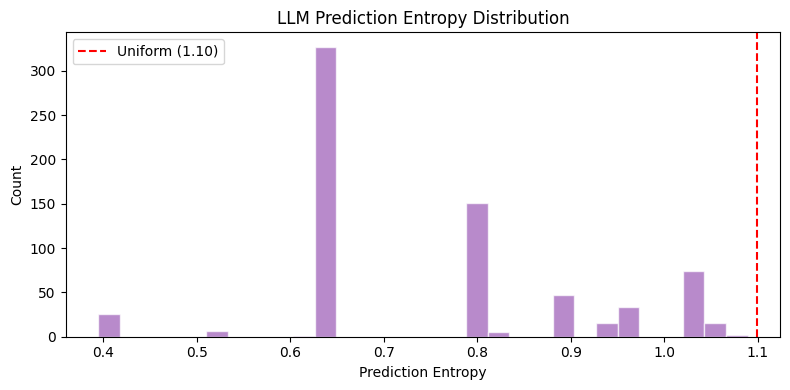

In [12]:
# Analyze LLM prediction entropy and stat-optimal adherence
llm_entropies = []
llm_argmax_matches_optimal = 0
llm_argmax_matches_actual = 0
llm_total = 0

for rec_idx, rec in enumerate(team_records):
    optimal_combo = rec['optimal_roles']
    for s, human_combo in enumerate(rec['stage_roles']):
        preds = llm_predictions.get(rec_idx, {}).get(s)
        if preds is None:
            continue
        for pos in range(3):
            marg = preds[pos]
            # Entropy
            h = -np.sum(marg * np.log(marg + 1e-20))
            llm_entropies.append(h)
            # Argmax vs optimal
            pred_role = np.argmax(marg)
            if pred_role == ROLE_CHAR_TO_IDX[optimal_combo[pos]]:
                llm_argmax_matches_optimal += 1
            if pred_role == ROLE_CHAR_TO_IDX[human_combo[pos]]:
                llm_argmax_matches_actual += 1
            llm_total += 1

print(f"LLM Prediction Analysis ({llm_total} player-stage predictions):\n")
print(f"  Mean entropy: {np.mean(llm_entropies):.3f} (uniform={np.log(3):.3f})")
print(f"  Argmax accuracy (vs actual):    {llm_argmax_matches_actual/llm_total:.1%}")
print(f"  Argmax = stat-optimal:          {llm_argmax_matches_optimal/llm_total:.1%}")

# Entropy histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(llm_entropies, bins=30, color='#9b59b6', alpha=0.7, edgecolor='white')
ax.axvline(x=np.log(3), color='red', linestyle='--', label=f'Uniform ({np.log(3):.2f})')
ax.set_xlabel('Prediction Entropy')
ax.set_ylabel('Count')
ax.set_title('LLM Prediction Entropy Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('analysis/experiments/2026-03-29_llm_baseline/llm_entropy.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

### Model Comparison

| Model | combo_r | marg_r | Mean LL/stage |
|-------|---------|--------|---------------|
| **Bayesian-Belief** | **0.4732** | 0.3582 | **-0.8748** |
| **LLM (Gemini Flash Lite)** | 0.4234 | 0.3437 | -0.9577 |
| Random Walk | 0.3855 | **0.4576** | -0.9384 |
| Bayesian-Value | 0.3728 | 0.5114 | -1.5405 |
| Random | 0.1567 | 0.0000 | -1.0986 |

### Key Findings

1. **LLM beats Random but falls short of Bayesian-Belief**: The LLM achieves combo_r=0.42 (vs BB's 0.47) and mean LL/stage=-0.96 (vs BB's -0.87). It clearly outperforms Random (combo_r=0.16) but doesn't match the Bayesian models.

2. **LLM heavily relies on stat-optimal heuristic**: 71.8% of argmax predictions match stat-optimal roles. The LLM essentially learned "pick the role matching your best stat" from the prompt description, which is a reasonable but incomplete model of human behavior.

3. **Good calibration**: 100% parse success rate, mean prediction entropy of 0.755 (between uniform=1.10 and deterministic=0). The LLM produces genuinely probabilistic outputs, not just point predictions.

4. **Argmax accuracy of 55.8%**: Better than chance (33%), confirming the LLM captures real behavioral patterns.

5. **No parameter fitting**: Unlike Bayesian-Belief (tau_prior=2.0, epsilon=0.5) and Random Walk (eps=0.38), the LLM has zero fitted parameters — its performance comes purely from in-context reasoning about the game rules and history.